# 🧠 Обнаружение инсайдерских угроз с помощью Bi-LSTM

**Подход:** NLP-анализ последовательностей действий пользователей

Данный ноутбук обучает двунаправленную LSTM (Bi-LSTM) нейросеть на токенизированных
последовательностях действий пользователей из датасета CERT Insider Threat r5.2.

**Конвейер данных:**
1. Сырые логи (logon, email, file, device, http) были токенизированы локально
2. Каждый день пользователя = одна последовательность токенов
3. Метки: 0 = нормальное поведение, 1 = инсайдерская атака (из answers/)

**Архитектура модели:**
- Embedding → Bi-LSTM → Dropout → Linear → Sigmoid

## 1. Установка зависимостей и импорт библиотек

In [2]:
import numpy as np
import json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_recall_fscore_support,
    roc_curve, auc, precision_recall_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Проверяем GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Используемое устройство: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Память GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} ГБ')

Используемое устройство: cuda
GPU: Tesla T4
Память GPU: 15.6 ГБ


## 2. Загрузка подготовленного датасета

Загрузите файл `cert_nlp_sequences.npz`, подготовленный локальным скриптом.
Используйте один из двух способов:
- **Способ A:** Загрузка через Google Drive (рекомендуется)
- **Способ B:** Прямая загрузка через интерфейс Colab

In [3]:
# ===== Способ A: Google Drive =====
# Раскомментируйте, если файл лежит на Google Диске

# from google.colab import drive
# drive.mount('/content/drive')
# DATA_PATH = '/content/drive/MyDrive/cert_nlp_sequences.npz'

# ===== Способ B: Прямая загрузка =====
# Раскомментируйте, если хотите загрузить файл вручную

from google.colab import files
DATA_PATH = 'cert_nlp_sequences.npz'

## 3. Исследование загруженных данных

In [4]:
# Загружаем данные
data = np.load(DATA_PATH, allow_pickle=True)

X = data['X']
y = data['y']
users = data['users']
dates = data['dates']
metadata = json.loads(str(data['metadata']))

print('=' * 60)
print('МЕТАДАННЫЕ ДАТАСЕТА')
print('=' * 60)
for k, v in metadata.items():
    if k != 'token_map':
        print(f'  {k}: {v}')

print(f'\nРазмер X (последовательности): {X.shape}')
print(f'Размер y (метки): {y.shape}')
print(f'\nБаланс классов:')
print(f'  Нормальные дни (0): {(y == 0).sum():,}')
print(f'  Дни с атаками (1): {(y == 1).sum():,}')
print(f'  Доля атак: {y.mean() * 100:.4f}%')

# Словарь токенов
token_map = metadata['token_map']
inv_token_map = {v: k for k, v in token_map.items()}
VOCAB_SIZE = metadata['vocab_size']
MAX_SEQ_LEN = metadata['max_seq_len']

print(f'\nСловарь токенов ({VOCAB_SIZE} элементов):')
for name, idx in sorted(token_map.items(), key=lambda x: x[1]):
    print(f'  {idx:3d} -> {name}')

МЕТАДАННЫЕ ДАТАСЕТА
  vocab_size: 19
  max_seq_len: 200
  num_sequences: 693649
  num_positive: 1307

Размер X (последовательности): (693649, 200)
Размер y (метки): (693649,)

Баланс классов:
  Нормальные дни (0): 692,342
  Дни с атаками (1): 1,307
  Доля атак: 0.1884%

Словарь токенов (19 элементов):
    0 -> <PAD>
    1 -> <UNK>
    2 -> LOGON
    3 -> LOGOFF
    4 -> USB_CONNECT
    5 -> USB_DISCONNECT
    6 -> FILE_OPEN
    7 -> FILE_WRITE
    8 -> FILE_COPY
    9 -> FILE_DELETE
   10 -> FILE_OPEN_USB
   11 -> FILE_WRITE_USB
   12 -> FILE_COPY_USB
   13 -> FILE_DELETE_USB
   14 -> EMAIL_SEND_INT
   15 -> EMAIL_SEND_EXT
   16 -> HTTP_BROWSE
   17 -> HTTP_UPLOAD
   18 -> HTTP_DOWNLOAD


## 4. Визуализация распределения токенов

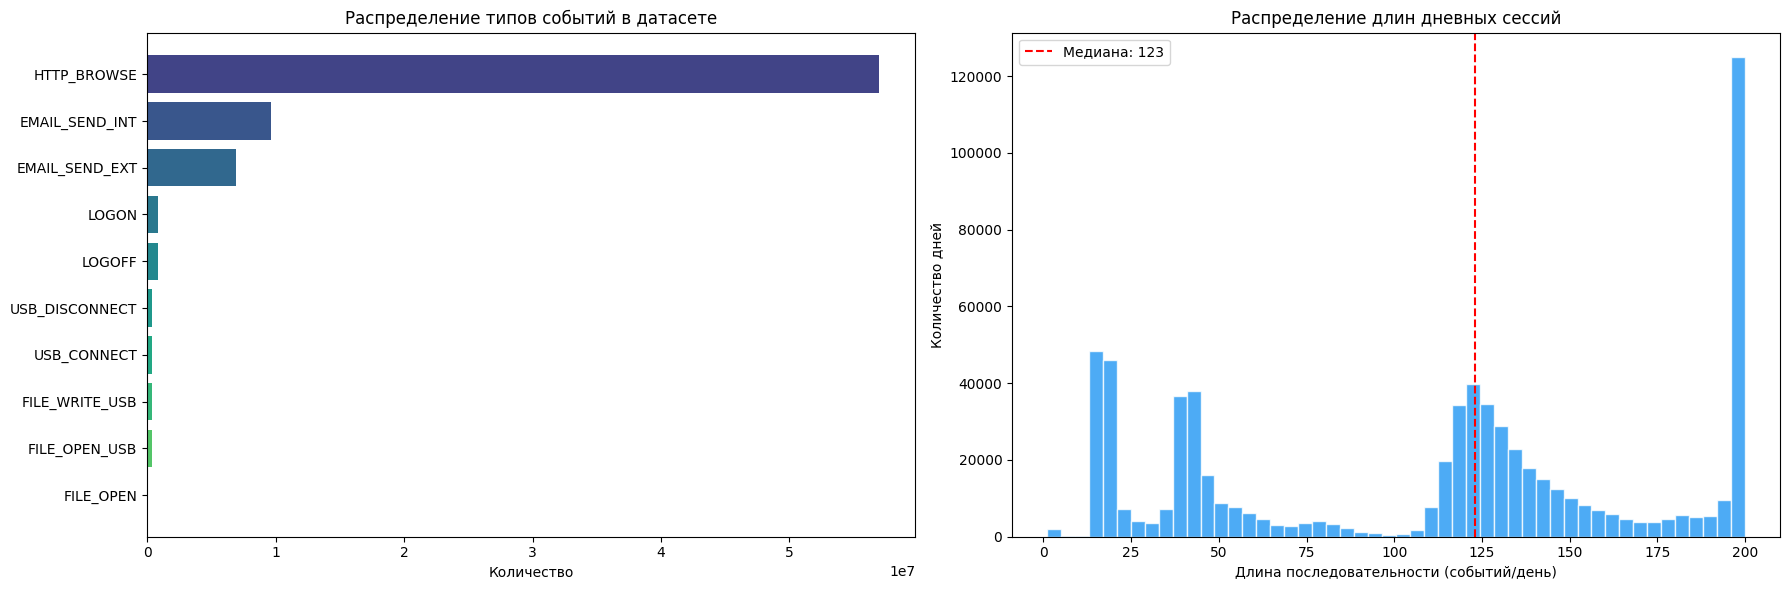

In [5]:
# Распределение токенов (без PAD)
flat_tokens = X[X > 0].flatten()
token_names = [inv_token_map.get(t, f'UNK_{t}') for t in range(1, VOCAB_SIZE)]
token_counts = [(inv_token_map.get(t, f'UNK_{t}'), (flat_tokens == t).sum())
                for t in range(1, VOCAB_SIZE)]
token_counts.sort(key=lambda x: -x[1])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Гистограмма токенов
names = [tc[0] for tc in token_counts if tc[1] > 0]
counts = [tc[1] for tc in token_counts if tc[1] > 0]
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(names)))
axes[0].barh(names, counts, color=colors)
axes[0].set_xlabel('Количество')
axes[0].set_title('Распределение типов событий в датасете')
axes[0].invert_yaxis()

# Распределение длин последовательностей
seq_lengths = (X > 0).sum(axis=1)
axes[1].hist(seq_lengths, bins=50, color='#2196F3', edgecolor='white', alpha=0.8)
axes[1].axvline(x=np.median(seq_lengths), color='red', linestyle='--',
                label=f'Медиана: {np.median(seq_lengths):.0f}')
axes[1].set_xlabel('Длина последовательности (событий/день)')
axes[1].set_ylabel('Количество дней')
axes[1].set_title('Распределение длин дневных сессий')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Подготовка данных для PyTorch

In [6]:
class InsiderThreatDataset(Dataset):
    """PyTorch Dataset для последовательностей действий пользователей."""
    def __init__(self, sequences, labels):
        self.sequences = torch.LongTensor(sequences)
        self.labels = torch.FloatTensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]


# ---- Разделение на train/test ----
# Разделяем по пользователям, чтобы модель училась обобщать на новых людей
unique_users = np.unique(users)
np.random.seed(42)
np.random.shuffle(unique_users)

split_idx = int(len(unique_users) * 0.8)
train_users = set(unique_users[:split_idx])
test_users = set(unique_users[split_idx:])

train_mask = np.array([u in train_users for u in users])
test_mask = ~train_mask

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f'Train: {len(X_train):,} последовательностей ({y_train.sum():,} атак, {y_train.mean()*100:.3f}%)')
print(f'Test:  {len(X_test):,} последовательностей ({y_test.sum():,} атак, {y_test.mean()*100:.3f}%)')

# ---- DataLoader с балансировкой (WeightedRandomSampler) ----
# Считаем веса для борьбы с дисбалансом классов
class_counts = np.bincount(y_train)
class_weights = 1.0 / class_counts
sample_weights = class_weights[y_train]
sampler = torch.utils.data.WeightedRandomSampler(
    weights=sample_weights, num_samples=len(sample_weights), replacement=True
)

BATCH_SIZE = 256

train_dataset = InsiderThreatDataset(X_train, y_train)
test_dataset = InsiderThreatDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'\nBatch size: {BATCH_SIZE}')
print(f'Train batches: {len(train_loader)}')
print(f'Test batches: {len(test_loader)}')

Train: 556,793 последовательностей (987 атак, 0.177%)
Test:  136,856 последовательностей (320 атак, 0.234%)

Batch size: 256
Train batches: 2175
Test batches: 535


## 6. Архитектура Bi-LSTM классификатора

Модель состоит из:
- **Embedding слой** — преобразует ID действий в плотные векторы
- **Bi-LSTM** — двунаправленная LSTM, анализирует последовательность событий
- **Attention-pooling** — взвешенное суммирование скрытых состояний
- **Classifier head** — полносвязные слои с Dropout

In [7]:
class BiLSTMClassifier(nn.Module):
    """
    Двунаправленная LSTM для классификации последовательностей действий пользователя.
    """
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128,
                 num_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0,
        )
        # Attention mechanism
        self.attention = nn.Linear(hidden_dim * 2, 1)
        # Classifier head
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        # x shape: (batch, seq_len)
        mask = (x != 0).float()  # (batch, seq_len) - маска для паддинга
        emb = self.embedding(x)  # (batch, seq_len, embed_dim)
        lstm_out, _ = self.lstm(emb)  # (batch, seq_len, hidden_dim*2)

        # Attention pooling
        attn_weights = self.attention(lstm_out).squeeze(-1)  # (batch, seq_len)
        attn_weights = attn_weights.masked_fill(mask == 0, float('-inf'))
        attn_weights = torch.softmax(attn_weights, dim=1)  # (batch, seq_len)
        context = torch.bmm(attn_weights.unsqueeze(1), lstm_out).squeeze(1)  # (batch, hidden*2)

        logits = self.classifier(context)  # (batch, 1)
        return logits.squeeze(-1)


# Создаем модель
model = BiLSTMClassifier(
    vocab_size=VOCAB_SIZE,
    embed_dim=64,
    hidden_dim=128,
    num_layers=2,
    dropout=0.3,
).to(device)

# Подсчет параметров
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Всего параметров: {total_params:,}')
print(f'Обучаемых параметров: {trainable_params:,}')
print()
print(model)

Всего параметров: 611,906
Обучаемых параметров: 611,906

BiLSTMClassifier(
  (embedding): Embedding(19, 64, padding_idx=0)
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): Linear(in_features=256, out_features=1, bias=True)
  (classifier): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=256, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)


## 7. Обучение модели

In [9]:
# ---- Гиперпараметры ----
NUM_EPOCHS = 15
LEARNING_RATE = 1e-3

# Используем классический BCEWithLogitsLoss без pos_weight, так как
# мы УЖЕ используем WeightedRandomSampler, который балансирует батчи 50/50.
# Использование обоих методов приведет к огромному количеству False Positives.
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

print(f'Эпох: {NUM_EPOCHS}, Learning Rate: {LEARNING_RATE}')

# ---- Training Loop ----
train_losses = []
val_losses = []
val_f1_scores = []
best_f1 = 0.0
best_model_state = None

for epoch in range(NUM_EPOCHS):
    # --- Train ---
    model.train()
    running_loss = 0.0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        logits = model(batch_X)
        loss = criterion(logits, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running_loss += loss.item() * batch_X.size(0)

    epoch_train_loss = running_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)

    # --- Validation ---
    model.eval()
    val_loss = 0.0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            logits = model(batch_X)
            loss = criterion(logits, batch_y)
            val_loss += loss.item() * batch_X.size(0)
            probs = torch.sigmoid(logits)
            all_preds.extend(probs.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())

    epoch_val_loss = val_loss / len(test_dataset)
    val_losses.append(epoch_val_loss)

    # F1-score на валидации
    preds_binary = (np.array(all_preds) > 0.5).astype(int)
    prec, rec, f1, _ = precision_recall_fscore_support(
        all_labels, preds_binary, average='binary', zero_division=0
    )
    val_f1_scores.append(f1)

    # Сохраняем лучшую модель
    if f1 > best_f1:
        best_f1 = f1
        best_model_state = model.state_dict().copy()
        marker = ' ★ best'
    else:
        marker = ''

    scheduler.step(epoch_val_loss)

    print(f'Epoch {epoch+1:2d}/{NUM_EPOCHS} | '
          f'Train Loss: {epoch_train_loss:.4f} | '
          f'Val Loss: {epoch_val_loss:.4f} | '
          f'P={prec:.4f} R={rec:.4f} F1={f1:.4f}{marker}')

print(f'\n✅ Лучший F1-score: {best_f1:.4f}')
# Загружаем лучшую модель
model.load_state_dict(best_model_state)

Эпох: 15, Learning Rate: 0.001
Epoch  1/15 | Train Loss: 0.1216 | Val Loss: 0.0840 | P=0.0596 R=0.6719 F1=0.1094 ★ best
Epoch  2/15 | Train Loss: 0.0418 | Val Loss: 0.0494 | P=0.0869 R=0.5125 F1=0.1486 ★ best
Epoch  3/15 | Train Loss: 0.0320 | Val Loss: 0.0430 | P=0.0973 R=0.4281 F1=0.1586 ★ best
Epoch  4/15 | Train Loss: 0.0260 | Val Loss: 0.0566 | P=0.0802 R=0.4813 F1=0.1374
Epoch  5/15 | Train Loss: 0.0231 | Val Loss: 0.0474 | P=0.0902 R=0.4469 F1=0.1501
Epoch  6/15 | Train Loss: 0.0211 | Val Loss: 0.0437 | P=0.1114 R=0.4344 F1=0.1773 ★ best
Epoch  7/15 | Train Loss: 0.0187 | Val Loss: 0.0477 | P=0.0956 R=0.4437 F1=0.1573
Epoch  8/15 | Train Loss: 0.0098 | Val Loss: 0.0435 | P=0.1212 R=0.3750 F1=0.1832 ★ best
Epoch  9/15 | Train Loss: 0.0102 | Val Loss: 0.0373 | P=0.1327 R=0.3906 F1=0.1981 ★ best
Epoch 10/15 | Train Loss: 0.0097 | Val Loss: 0.0439 | P=0.1137 R=0.4031 F1=0.1773
Epoch 11/15 | Train Loss: 0.0093 | Val Loss: 0.0395 | P=0.1299 R=0.3969 F1=0.1957
Epoch 12/15 | Train Loss:

<All keys matched successfully>

## 8. Кривые обучения

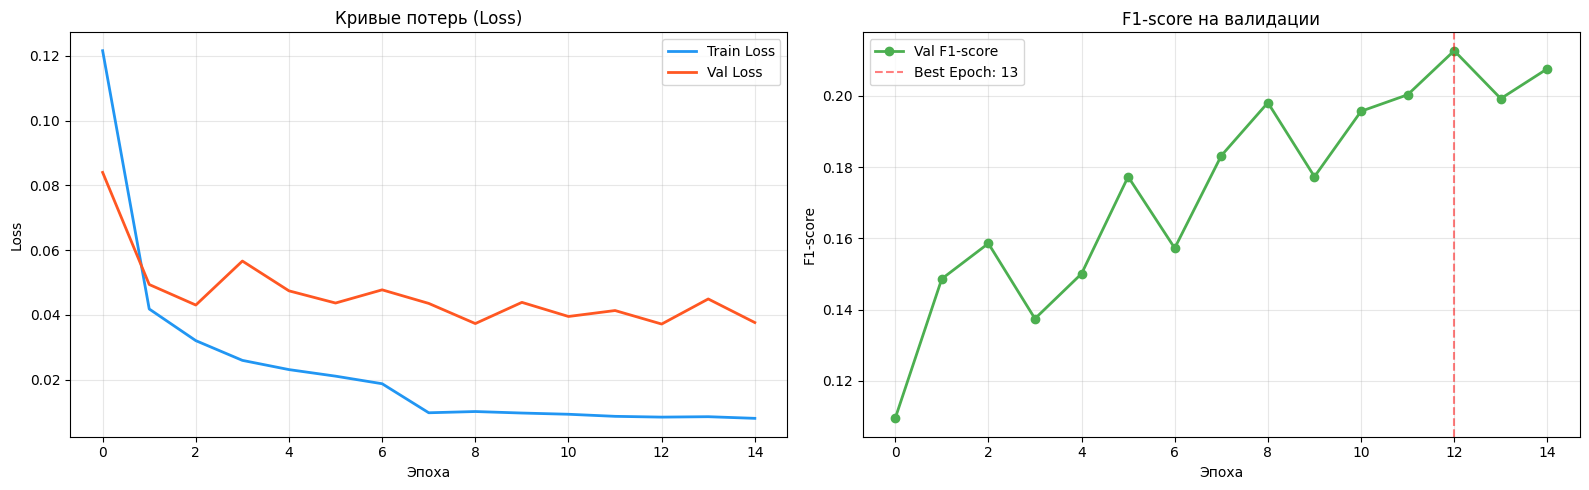

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss
axes[0].plot(train_losses, label='Train Loss', color='#2196F3', linewidth=2)
axes[0].plot(val_losses, label='Val Loss', color='#FF5722', linewidth=2)
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss')
axes[0].set_title('Кривые потерь (Loss)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# F1-score
axes[1].plot(val_f1_scores, label='Val F1-score', color='#4CAF50', linewidth=2, marker='o')
best_epoch = np.argmax(val_f1_scores)
axes[1].axvline(x=best_epoch, color='red', linestyle='--', alpha=0.5,
                label=f'Best Epoch: {best_epoch+1}')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('F1-score')
axes[1].set_title('F1-score на валидации')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Подбор оптимального порога классификации

Порог 0.5 не всегда оптимален. Подберем порог, максимизирующий F1-score.

Оптимальный порог (по F2-score): 0.180
F2-score при оптимальном пороге: 0.2868


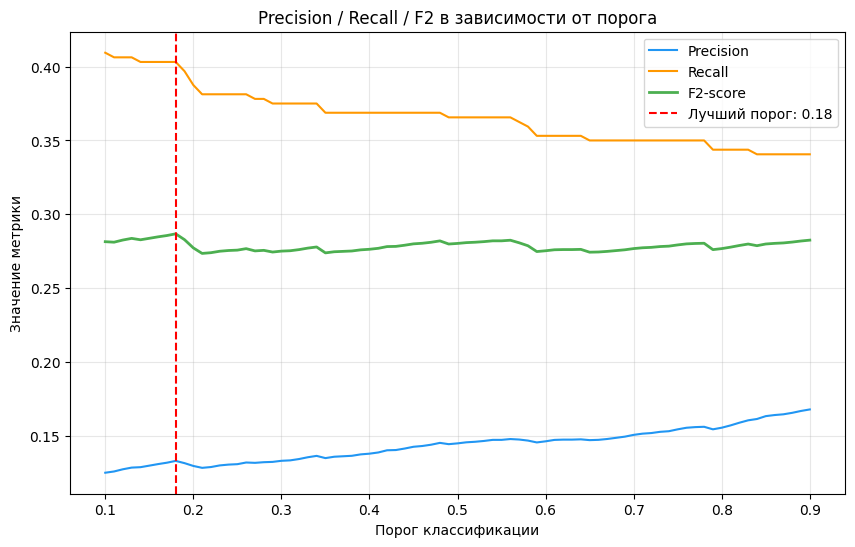

In [15]:
from sklearn.metrics import fbeta_score
# Получаем вероятности на тестовой выборке
model.eval()
all_probs = []
all_true = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        logits = model(batch_X)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.extend(probs)
        all_true.extend(batch_y.numpy())

all_probs = np.array(all_probs)
all_true = np.array(all_true)

# Перебор порогов
thresholds = np.linspace(0.1, 0.9, 81)
best_threshold = 0.5
best_f2 = 0.0
results = []

for thresh in thresholds:
    preds = (all_probs >= thresh).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(
        all_true, preds, average='binary', zero_division=0
    )
    f2 = fbeta_score(all_true, preds, beta=2)
    results.append((thresh, p, r, f1, f2))

    if f2 > best_f2:
        best_f2 = f2
        best_threshold = thresh

print(f'Оптимальный порог (по F2-score): {best_threshold:.3f}')
print(f'F2-score при оптимальном пороге: {best_f2:.4f}')

# Визуализация
results = np.array(results)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(results[:, 0], results[:, 1], label='Precision', color='#2196F3')
ax.plot(results[:, 0], results[:, 2], label='Recall', color='#FF9800')
ax.plot(results[:, 0], results[:, 4], label='F2-score', color='#4CAF50', linewidth=2)
ax.axvline(x=best_threshold, color='red', linestyle='--',
           label=f'Лучший порог: {best_threshold:.2f}')
ax.set_xlabel('Порог классификации')
ax.set_ylabel('Значение метрики')
ax.set_title('Precision / Recall / F2 в зависимости от порога')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


## 10. Итоговая оценка модели

ИТОГОВЫЕ РЕЗУЛЬТАТЫ Bi-LSTM КЛАССИФИКАТОРА
Порог: 0.94

              precision    recall  f1-score   support

  Нормальное     0.9984    0.9964    0.9974    136536
    Инсайдер     0.1783    0.3344    0.2326       320

    accuracy                         0.9948    136856
   macro avg     0.5884    0.6654    0.6150    136856
weighted avg     0.9965    0.9948    0.9956    136856



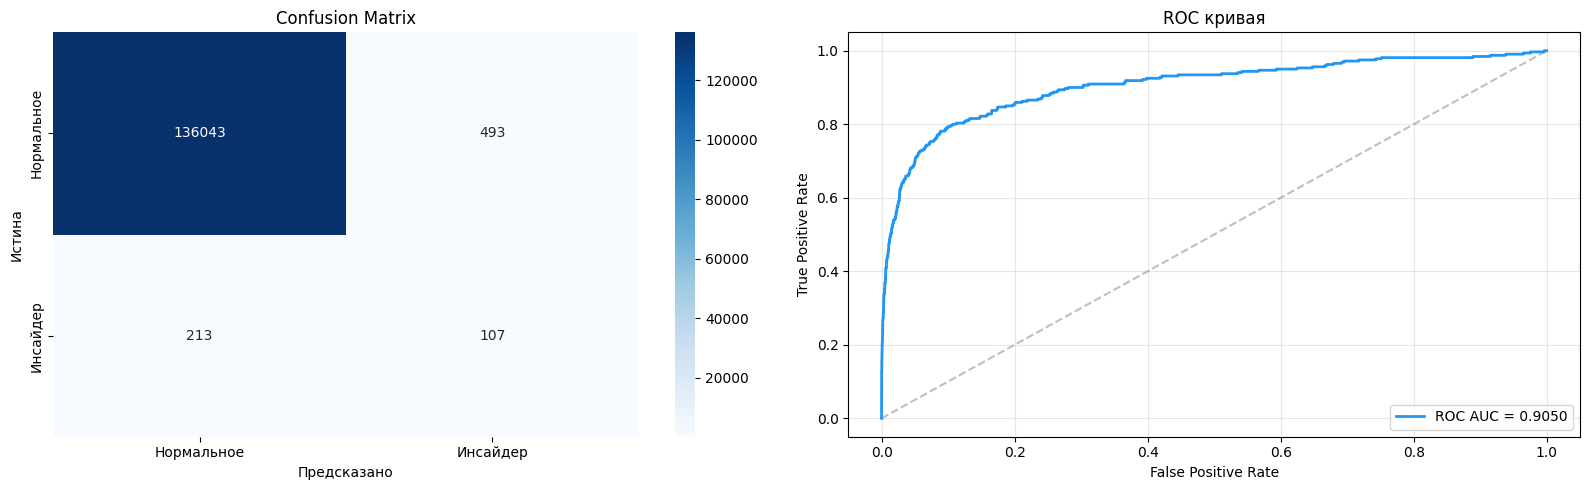

In [12]:
# Финальные предсказания с оптимальным порогом
final_preds = (all_probs >= best_threshold).astype(int)

print('=' * 60)
print('ИТОГОВЫЕ РЕЗУЛЬТАТЫ Bi-LSTM КЛАССИФИКАТОРА')
print('=' * 60)
print(f'Порог: {best_threshold:.2f}')
print()
print(classification_report(all_true, final_preds,
                            target_names=['Нормальное', 'Инсайдер'],
                            digits=4))

# Confusion Matrix
cm = confusion_matrix(all_true, final_preds)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Нормальное', 'Инсайдер'],
            yticklabels=['Нормальное', 'Инсайдер'])
axes[0].set_xlabel('Предсказано')
axes[0].set_ylabel('Истина')
axes[0].set_title('Confusion Matrix')

# ROC Curve
fpr, tpr, _ = roc_curve(all_true, all_probs)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#2196F3', linewidth=2,
             label=f'ROC AUC = {roc_auc:.4f}')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC кривая')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Сохранение обученной модели

In [13]:
# Сохраняем модель и метаданные
save_dict = {
    'model_state_dict': model.state_dict(),
    'vocab_size': VOCAB_SIZE,
    'max_seq_len': MAX_SEQ_LEN,
    'token_map': token_map,
    'best_threshold': best_threshold,
    'best_f1': best_f1_thresh,
    'embed_dim': 64,
    'hidden_dim': 128,
    'num_layers': 2,
    'dropout': 0.3,
}

torch.save(save_dict, 'bilstm_insider_threat.pth')
print('Модель сохранена: bilstm_insider_threat.pth')

# Скачиваем модель
from google.colab import files
files.download('bilstm_insider_threat.pth')

Модель сохранена: bilstm_insider_threat.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 12. Сравнение с другими моделями

Сравните результаты Bi-LSTM с ранее полученными результатами на агрегированных данных.

In [14]:
# Вставьте результаты из основного ноутбука для сравнения
comparison = {
    'Isolation Forest (Baseline)': {'Precision': 0.0065, 'Recall': 0.0736, 'F1': 0.0119},
    'Autoencoder (Baseline)': {'Precision': 0.0373, 'Recall': 0.2121, 'F1': 0.0634},
    'Random Forest + SMOTE': {'Precision': 0.2898, 'Recall': 0.6780, 'F1': 0.4061},
    'XGBoost + SMOTE': {'Precision': 0.3747, 'Recall': 0.7231, 'F1': 0.4936},
    'LightGBM + SMOTE': {'Precision': 0.3972, 'Recall': 0.7363, 'F1': 0.5160},
}

# Добавляем результат Bi-LSTM
p_final, r_final, f1_final, _ = precision_recall_fscore_support(
    all_true, final_preds, average='binary', zero_division=0
)
comparison['Bi-LSTM (NLP)'] = {
    'Precision': round(p_final, 4),
    'Recall': round(r_final, 4),
    'F1': round(f1_final, 4),
}

print(f'{"Модель":<35} {"Precision":>10} {"Recall":>10} {"F1-score":>10}')
print('-' * 67)
for name, metrics in comparison.items():
    print(f'{name:<35} {metrics["Precision"]:>10.4f} {metrics["Recall"]:>10.4f} {metrics["F1"]:>10.4f}')

Модель                               Precision     Recall   F1-score
-------------------------------------------------------------------
Isolation Forest (Baseline)             0.0065     0.0736     0.0119
Autoencoder (Baseline)                  0.0373     0.2121     0.0634
Random Forest + SMOTE                   0.2898     0.6780     0.4061
XGBoost + SMOTE                         0.3747     0.7231     0.4936
LightGBM + SMOTE                        0.3972     0.7363     0.5160
Bi-LSTM (NLP)                           0.1783     0.3344     0.2326
